# 04a · Ortak, Marjinal ve Koşullu Dağılımlar (Joint, Marginal, Conditional)
**Probability Lab** · Joint Distributions

---
> **Bu notebook'ta ne öğreneceğiz?**  
> Bugüne kadar tek bir değişkeni (X) inceledik. Ama gerçek hayatta değişkenler **birlikte** hareket eder.  
> Boy ve kilo; ev yaşı ve ev fiyatı; eğitim ve maaş...  
> - İkisine birden bakmaya **Ortak (Joint)**,  
> - Birlikteyken sadece birini umursamaya **Marjinal (Marginal)**,  
> - Birini sabitleyip diğerine bakmaya **Koşullu (Conditional)** diyoruz.

**Önkoşul:** PDF/CDF kavramları (01_foundations), Sürekli Dağılımlar (03_continuous_distributions)  
**Veri:**  
- `seaborn.penguins` — Penguen türleri, gaga ve kanat uzunlukları  
- `seaborn.diamonds` — Elmas karat, kesim ve fiyat bilgileri  
- `sklearn.datasets.fetch_california_housing` (Egzersiz için)  
**Araçlar:** Python (seaborn, scipy), R (ggplot2), SQL (DuckDB)

# 1 · Teorik Temeller: Ortak, Marjinal ve Koşullu Dağılımlar

İki rassal değişkenimiz olsun: $X$ ve $Y$.

## 1.1 Ortak Dağılım (Joint Distribution)

Ortak dağılım, iki rassal değişkenin aynı anda belirli değerleri alma olasılığını (kesikli durumda) veya olasılık yoğunluğunu (sürekli durumda) ifade eder.

**Kesikli (PMF):**
$$P(X=x,\ Y=y)$$

*Örnek:* İki zarın da 6 gelme olasılığı.

**Sürekli (PDF):**
$$f_{X,Y}(x,y)$$

*Örnek:* Bir kişinin boyunun 180 cm ve kilosunun 75 kg civarında olmasına karşılık gelen ortak yoğunluk.

Sürekli değişkenlerde belirli bir bölgedeki olasılık, ortak yoğunluk fonksiyonunun o bölge üzerindeki integralidir:

$$P((X,Y) \in A) = \iint_A f_{X,Y}(x,y)\,dx\,dy$$

---

## 1.2 Marjinal Dağılım (Marginal Distribution)

Marjinal dağılım, yalnızca bir değişkenin dağılımını elde etmek için diğer değişkenin etkisini ortadan kaldırır.

Başka bir ifadeyle:

> "Y'nin hangi değeri aldığı önemli değil; yalnızca X'in dağılımını istiyorum."

Bunun için ortak dağılım üzerinden diğer değişken toplanır (kesikli) veya integrali alınır (sürekli).

### Sürekli durumda

$$f_X(x) = \int_{-\infty}^{\infty} f_{X,Y}(x,y)\,dy$$

### Kesikli durumda

$$P(X=x) = \sum_y P(X=x,\ Y=y)$$

### Neden "Marjinal" denir?

Eskiden olasılık tablolarında satır ve sütun toplamları tablonun kenarına (**margin**) yazıldığı için bu dağılıma **marjinal dağılım** adı verilmiştir.

---

## 1.3 Koşullu Dağılım (Conditional Distribution)

Koşullu dağılım, bir değişkenin değeri bilindiğinde diğer değişkenin dağılımının nasıl değiştiğini gösterir.

Örneğin:

> "Y'nin $y$ olduğunu biliyorsam, X nasıl dağılır?"

Sürekli durumda:

$$f_{X\mid Y}(x\mid y) = \frac{f_{X,Y}(x,y)}{f_Y(y)}, \qquad f_Y(y) > 0$$

Yani,

> **Koşullu dağılım = Ortak dağılım / Marjinal dağılım**

Bu ilişki Bayes Teoremi'nin temelini oluşturur.

---

## 1.4 Bağımsızlık (Independence)

İki rassal değişken birbirinden bağımsızsa, birinin değerini bilmek diğerinin dağılımını değiştirmez.

Yani,

$$f_{X\mid Y}(x\mid y) = f_X(x)$$

Bu ifade koşullu dağılım formülüne yerleştirildiğinde bağımsızlığın temel koşulu elde edilir:

$$f_{X,Y}(x,y) = f_X(x)\,f_Y(y)$$

Kesikli değişkenler için de benzer şekilde,

$$P(X=x,\ Y=y) = P(X=x)\,P(Y=y)$$

eşitliği sağlanır.

---

## 🎯 Pratik Yorum

Bu dört kavram birbirleriyle doğrudan ilişkilidir:

- **Ortak dağılım**, iki değişkeni birlikte inceler.
- **Marjinal dağılım**, yalnızca tek bir değişkenin dağılımını verir.
- **Koşullu dağılım**, bir değişken bilindiğinde diğerinin dağılımını açıklar.
- **Bağımsızlık** ise ortak dağılımın marjinal dağılımların çarpımıyla ifade edilebilmesidir.

Bu nedenle birçok istatistiksel yöntem (Bayes Teoremi, Ki-Kare bağımsızlık testi, Naive Bayes sınıflandırıcısı ve olasılıksal grafik modelleri) bu dört temel kavram üzerine kuruludur.

---
# 🐍 Python Uygulaması

3 adımda pratik:
1. **2B Dağılım Görselleştirme:** Penguins verisinde `seaborn.jointplot` ile Ortak + Marjinal gösterim
2. **Ortak Dağılım Topografyası (KDE):** Yoğunluk haritaları (contour plot)
3. **Koşullu Dağılım Analizi:** Diamonds verisinde, bir değişkene koşullandığımızda dağılımın nasıl değiştiği

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Hazir ✓')


Hazir ✓


---
### 🐧 Python 1 — Joint ve Marginal Dağılımlar (Penguins)

**Veri:** `seaborn.penguins`
- `bill_length_mm` (Gaga uzunluğu)
- `bill_depth_mm` (Gaga kalınlığı)

**Araç:** `sns.jointplot`  
Bu fonksiyon, merkeze ortak (joint) dağılımı, eksenlerin kenarlarına (margins) ise tekil (marginal) dağılımları çizer.

Penguins Yuklendi: 333 satir


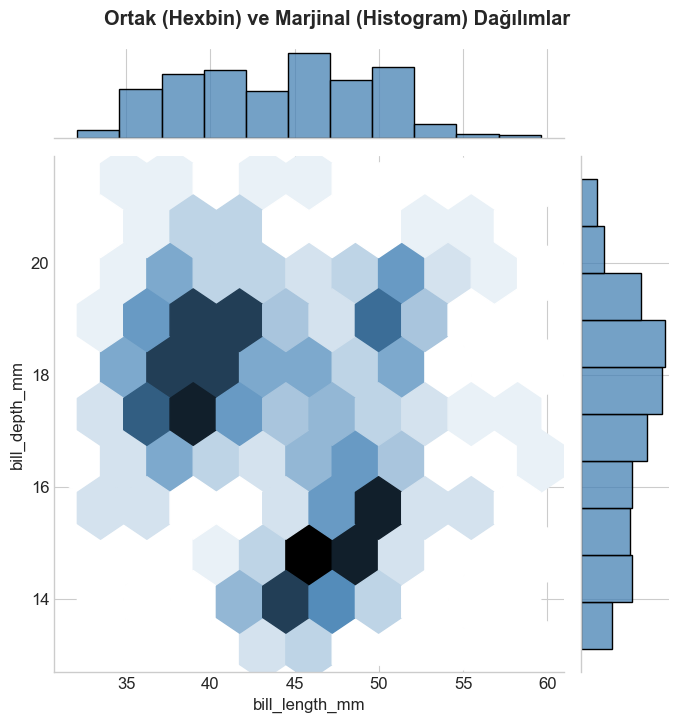

YORUM:
- Merkeze bak: Ortak (Joint) dağılım. Renk koyulastıkça o noktadaki yoğunluk (olasılık) artıyor.
- Tepeye bak: Sadece 'bill_length_mm' histogramı (Marjinal dağılım). Y eksenini unutup hepsini ezdik.
- Sağa bak: Sadece 'bill_depth_mm' histogramı (Marjinal dağılım). X eksenini ezdik.


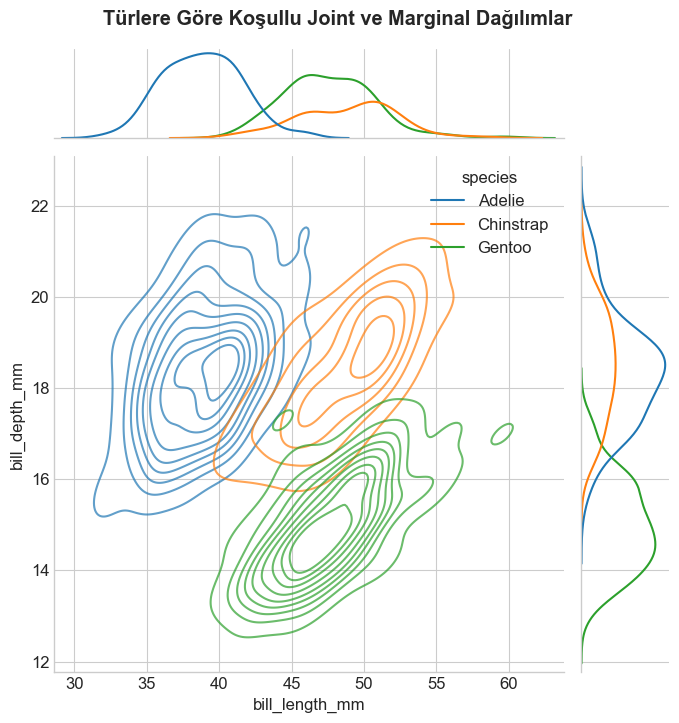

YORUM:
- Burada aslında 'Koşullu (Conditional)' bir bakış var.
- Örneğin Mavi eğriler: P(GagaUzunlugu, GagaKalinligi | Tür = Adelie)
- Toplam marjinal dağılımın (önceki grafik) aslında 3 farklı alt grubun birleşimi olduğunu görüyoruz.


In [2]:
penguins = sns.load_dataset('penguins').dropna()
print(f'Penguins Yuklendi: {len(penguins)} satir')

# ─── 1. JointPlot: Hexbin ile yogunluk gosterimi ──────────────────────────────
g = sns.jointplot(
    data=penguins, 
    x='bill_length_mm', 
    y='bill_depth_mm',
    kind='hex',        # Altıgen (hexagonal) kutularla 2D histogram
    color='steelblue',
    height=7
)
g.fig.suptitle('Ortak (Hexbin) ve Marjinal (Histogram) Dağılımlar', y=1.03, fontweight='bold')
plt.show()

print("YORUM:")
print("- Merkeze bak: Ortak (Joint) dağılım. Renk koyulastıkça o noktadaki yoğunluk (olasılık) artıyor.")
print("- Tepeye bak: Sadece 'bill_length_mm' histogramı (Marjinal dağılım). Y eksenini unutup hepsini ezdik.")
print("- Sağa bak: Sadece 'bill_depth_mm' histogramı (Marjinal dağılım). X eksenini ezdik.")

# ─── 2. JointPlot: KDE (Yoğunluk) Konturları ile ──────────────────────────────
g2 = sns.jointplot(
    data=penguins, 
    x='bill_length_mm', 
    y='bill_depth_mm',
    hue='species',     # Türlere göre ayır
    kind='kde',        # Kernel Density Estimation (2D Eğriler)
    height=7, 
    alpha=0.7
)
g2.fig.suptitle('Türlere Göre Koşullu Joint ve Marginal Dağılımlar', y=1.03, fontweight='bold')
plt.show()

print("YORUM:")
print("- Burada aslında 'Koşullu (Conditional)' bir bakış var.")
print("- Örneğin Mavi eğriler: P(GagaUzunlugu, GagaKalinligi | Tür = Adelie)")
print("- Toplam marjinal dağılımın (önceki grafik) aslında 3 farklı alt grubun birleşimi olduğunu görüyoruz.")


# Python 1 - Görsel Açıklamalar: Ortak, Marjinal ve Koşullu Dağılımlar

Bu iki grafik, Palmer Penguins veri setinden `bill_length_mm` (gaga uzunluğu) ve `bill_depth_mm` (gaga derinliği) değişkenleri kullanılarak üretilmiş — joint/marginal/conditional dağılım kavramlarının görsel karşılığı.

---

## Görsel 1: Koşulsuz Ortak + Marjinal Dağılım

### Ortadaki hexbin (altıgen) grafik = Ortak Dağılım $f_{X,Y}(x,y)$

X ekseni bill_length, Y ekseni bill_depth. Her altıgen, o bölgede kaç veri noktası düştüğünü gösteriyor — koyu renk çok veri, açık renk az veri anlamına geliyor. Bu, iki değişkenin **birlikte** nasıl dağıldığını gösteriyor:

$$P((X,Y) \in A) = \iint_A f_{X,Y}(x,y)\,dx\,dy$$

Koyu bölgeler, bu integralin büyük çıktığı yerler.

### Üstteki histogram = X'in Marjinal Dağılımı $f_X(x)$

Y'yi (bill_depth) tamamen görmezden gelip sadece bill_length'in tek başına dağılımını gösteriyor. Ortak dağılımı Y ekseni boyunca "toplayarak" (integralleyerek) elde edilir:

$$f_X(x) = \int_{-\infty}^{\infty} f_{X,Y}(x,y)\,dy$$

Ortadaki hexbin grafiğini yukarıdan aşağı "ezersen", üstteki histogram ortaya çıkar diye düşünebilirsin.

### Sağdaki histogram = Y'nin Marjinal Dağılımı $f_Y(y)$

Aynı mantık, bu sefer X'i görmezden gelip bill_depth'in tek başına dağılımı. Ortak grafiği soldan sağa ezersen sağdaki histogram çıkar.

### Neden "marjinal" (kenar) deniyor?

Histogramlar grafiğin *kenarlarında* duruyor — ortadaki ortak dağılımın kenara düşen "gölgesi" gibi.

---

## Görsel 2: Koşullu Dağılım — Türe Göre Ayrıştırma

Bu grafikte üç renkli kontur (eş-yükseklik eğrisi) var: mavi (Adelie), turuncu (Chinstrap), yeşil (Gentoo). Her renk, ayrı bir **koşullu ortak dağılım**:

$$f_{X,Y}(x,y \mid \text{species} = s)$$

Soru şu: *"Eğer penguenin Adelie olduğunu biliyorsam, bill_length ve bill_depth nasıl dağılır?"* Bu, koşullu dağılım formülünün

$$f_{X\mid Y}(x\mid y) = \frac{f_{X,Y}(x,y)}{f_Y(y)}$$

çok değişkenli bir uzantısı — burada koşullandığın şey sürekli bir değişken değil, **kategorik** bir değişken (tür).

### Kontur çizgilerinin anlamı

Her halka aynı yoğunluk seviyesini gösteriyor (topografik haritadaki yükseklik çizgileri gibi). İçteki halkalar en yoğun bölgeyi (o türün "tipik" gaga ölçülerini), dıştaki halkalar seyrek bölgeyi temsil ediyor.

### Görsel 1 ile 2'nin ilişkisi

Görsel 1'deki koyu bölgelerin (sol-üst ve sağ-alt olmak üzere iki ayrı yoğun küme) nedenini Görsel 2 açıklıyor: aslında üç farklı tür karışmış durumda, her biri kendi bölgesinde kümeleniyor. Görsel 1 tek bir ortak dağılım gibi görünse de, aslında üç ayrı koşullu dağılımın toplamı (species'e göre marjinalize edilmiş hali).

### Üstteki/sağdaki KDE eğrileri

Bunlar da yine marjinal dağılımlar, ama bu sefer *tür bazında* — her rengin kendi marjinal $f_X(x \mid \text{species})$ ve $f_Y(y \mid \text{species})$ eğrisi.

---

## Neden Bu Ayrım Önemli? (ML Bağlantısı)

Bu iki grafik aslında bir **sınıflandırma probleminin görselleştirmesi**:

- **Türleri bilmeden** (Görsel 1) bakarsan veri karmaşık ve iç içe görünür.
- **Koşullandığında** (Görsel 2, türe göre ayırdığında) her grup kendi içinde çok daha ayırt edilebilir hale gelir — mavi (Adelie) sol tarafta, yeşil (Gentoo) alt-sağda net ayrışıyor, turuncu (Chinstrap) biraz mavi ile örtüşüyor.

Bu tam olarak **Naive Bayes**'in mantığı: eğer $f(x,y \mid \text{sınıf})$'ı (her sınıf için koşullu dağılımı) biliyorsan, yeni bir gözlem geldiğinde Bayes teoremiyle hangi sınıfa ait olma olasılığının en yüksek olduğunu hesaplayabilirsin.

**Bağımsızlık açısından:** Eğer tür, bill_length/bill_depth'i hiç etkilemeseydi, üç renkteki kontur şekilleri birbirinin *aynısı* olurdu. Ama şekiller belirgin şekilde farklı — bu da türün gaga ölçüleriyle güçlü bir ilişkisi olduğunu, yani bu iki değişkenin türden bağımsız olmadığını gösteriyor.

### Özet

| | Görsel 1 | Görsel 2 |
|---|---|---|
| Gösterdiği | Koşulsuz ortak + marjinal dağılım | Türe göre koşullu ortak + marjinal dağılım |
| Formül | $f_{X,Y}(x,y)$ | $f_{X,Y}(x,y \mid \text{species})$ |
| Yorum | Genel resim, gruplar ayrılmamış | Gruplara göre ayırınca resim netleşiyor |

---
### 💎 Python 2 — Koşullu Dağılım Analizi (Diamonds)

**Veri:** `seaborn.diamonds`
- `price` (Fiyat)
- `cut` (Kesim kalitesi: Fair, Good, Very Good, Premium, Ideal)

**Soru:** Kesim kalitesini (Y) bildiğimizde, fiyat (X) dağılımı nasıl değişir?  
Yani $f(Price \mid Cut=c)$ nedir?

Diamonds Yuklendi: 53940 satir



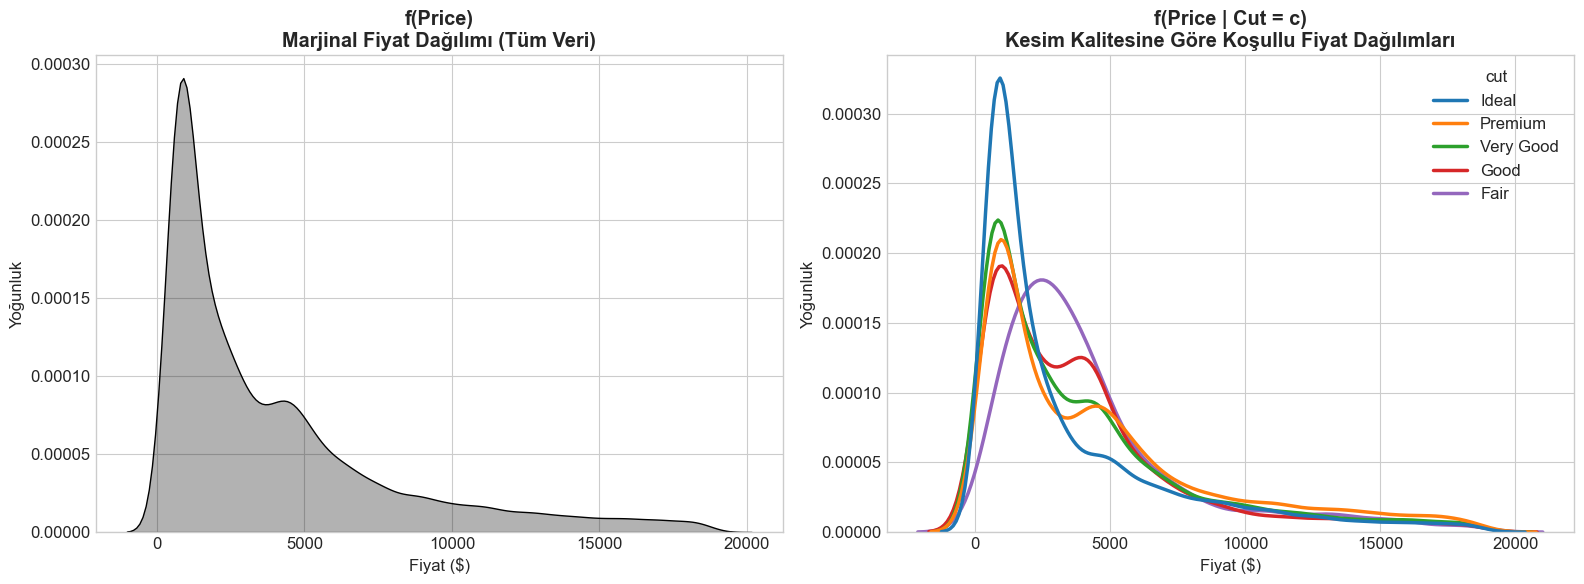

YORUM:
- Sol grafik marjinaldir: Y (Cut) değişkenini integrate edip yok ettik.
- Sağ grafik koşulludur: 'Eğer kesim Ideal ise fiyat budur' diyoruz.
- İlginç bir durum: 'Ideal' kesim elmasların yoğunluğu düşük fiyatlarda (0-2500$) daha fazla!
- Bu bize şunu gösterir: Fiyat sadece kesime bağlı DEĞİLDİR (muhtemelen Karat daha baskın bir değişkendir).


In [3]:
diamonds = sns.load_dataset('diamonds')
print(f'Diamonds Yuklendi: {len(diamonds)} satir\n')

# Fiyat (Marjinal Dağılım) vs Kesim Kalitesine Göre Koşullu Fiyat
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sol: Marjinal (Tüm Fiyatlar)
ax = axes[0]
sns.kdeplot(data=diamonds, x='price', ax=ax, color='black', fill=True, alpha=0.3)
ax.set_title('f(Price)\nMarjinal Fiyat Dağılımı (Tüm Veri)', fontweight='bold')
ax.set_xlabel('Fiyat ($)')
ax.set_ylabel('Yoğunluk')

# Sağ: Koşullu (Kesim Kalitesine Göre)
ax = axes[1]
sns.kdeplot(data=diamonds, x='price', hue='cut', ax=ax, common_norm=False, linewidth=2.5)
ax.set_title('f(Price | Cut = c)\nKesim Kalitesine Göre Koşullu Fiyat Dağılımları', fontweight='bold')
ax.set_xlabel('Fiyat ($)')
ax.set_ylabel('Yoğunluk')

plt.tight_layout()
plt.show()

print("YORUM:")
print("- Sol grafik marjinaldir: Y (Cut) değişkenini integrate edip yok ettik.")
print("- Sağ grafik koşulludur: 'Eğer kesim Ideal ise fiyat budur' diyoruz.")
print("- İlginç bir durum: 'Ideal' kesim elmasların yoğunluğu düşük fiyatlarda (0-2500$) daha fazla!")
print("- Bu bize şunu gösterir: Fiyat sadece kesime bağlı DEĞİLDİR (muhtemelen Karat daha baskın bir değişkendir).")


---
# 📊 R Uygulaması


In [4]:
%load_ext rpy2.ipython


Error importing in API mode: ImportError("dlopen(/opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <2F94BB47-26EE-3EB3-85C5-1EA8A83C71AB> /opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


---
# R1 Uygulaması

Python'da `sns.jointplot` ile yaptığımız 2D kontur grafiklerini R'da `ggplot2` kütüphanesinin `geom_density_2d()` ve `geom_density_2d_filled()` fonksiyonlarıyla yapacağız.


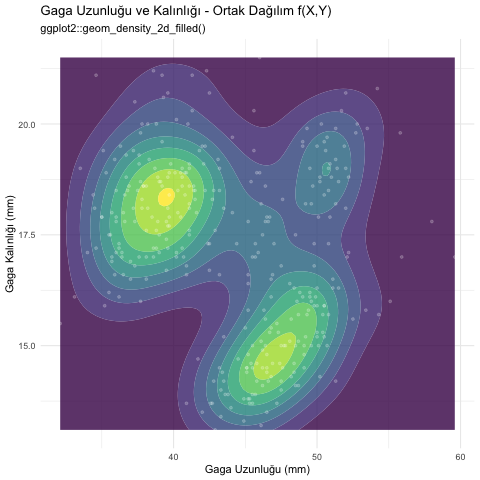

In [5]:
%%R -i penguins

library(ggplot2)

# Eksik verileri cikaralim
penguins_clean <- na.omit(penguins)

# 2D Yoğunluk Grafiği (Ortak Dağılım Topografyası)
p <- ggplot(penguins_clean, aes(x=bill_length_mm, y=bill_depth_mm)) +
  # geom_density_2d_filled: Yoğunluğa göre renkli harita çıkarır
  geom_density_2d_filled(alpha = 0.8) +
  # geom_point: Gerçek noktaları hafifçe gösterelim
  geom_point(color = "white", alpha = 0.2, size = 1) +
  theme_minimal() +
  labs(title = "Gaga Uzunluğu ve Kalınlığı - Ortak Dağılım f(X,Y)",
       subtitle = "ggplot2::geom_density_2d_filled()",
       x = "Gaga Uzunluğu (mm)", 
       y = "Gaga Kalınlığı (mm)") +
  theme(legend.position = "none") # Lejantı gizle

print(p)


---
# R2 Uygulaması — Penguins: Adaya Göre Koşullu Dağılım
`penguins` verisinde (R'a `-i penguins` ile zaten aktarılmıştı) `body_mass_g`'nin `island`'a göre koşullu yoğunluk dağılımlarını `ggplot2::geom_density()` ile (fill=island) çizelim. Hangi adadaki penguenler ortalama olarak daha ağır?


Ada bazında ortalama vücut kütlesi:
     island body_mass_g
1    Biscoe    4719.172
2     Dream    3718.902
3 Torgersen    3708.511


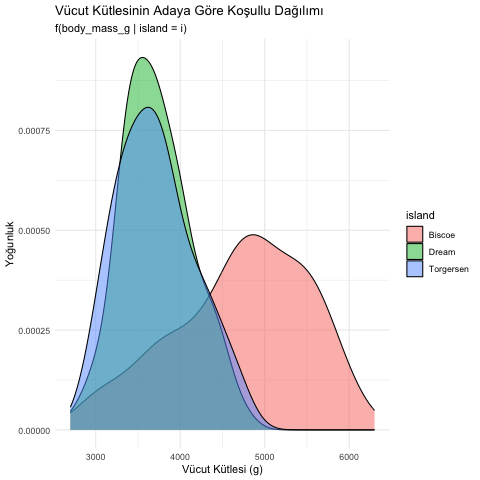

In [6]:
%%R -i penguins

library(ggplot2)
penguins_clean <- na.omit(penguins)

p <- ggplot(penguins_clean, aes(x = body_mass_g, fill = island)) +
  geom_density(alpha = 0.5) +
  theme_minimal() +
  labs(title = "Vücut Kütlesinin Adaya Göre Koşullu Dağılımı",
       subtitle = "f(body_mass_g | island = i)",
       x = "Vücut Kütlesi (g)", y = "Yoğunluk")
print(p)

cat("\nAda bazında ortalama vücut kütlesi:\n")
print(aggregate(body_mass_g ~ island, data = penguins_clean, FUN = mean))

---
# 🗄️ SQL Uygulaması (DuckDB)

SQL aslında bir veri manipülasyon dili olduğu kadar, **marjinalleştirme (GROUP BY)** ve **koşullandırma (WHERE)** işlemlerinin de anavatanıdır.

1. `GROUP BY` olmadan tüm tablo üzerinden `AVG()` almak → **Marjinal Beklenti (Marginal Expectation)**
2. `GROUP BY` veya `WHERE` kullanmak → **Koşullu Beklenti (Conditional Expectation) $E[X \mid Y]$**

In [7]:
import duckdb
con = duckdb.connect()
con.register('diamonds_tbl', diamonds)
con.register('penguins_tbl', penguins)
print('DuckDB hazir ✓')


DuckDB hazir ✓


In [8]:
sql_query = """
-- 1. Marjinal Beklenti E[Price]
WITH marginal AS (
    SELECT 
        'TÜM VERİ (Marjinal)' AS cut_kalitesi,
        COUNT(*) AS gozlem_sayisi,
        ROUND(AVG(price), 2) AS beklenen_fiyat
    FROM diamonds_tbl
),
-- 2. Koşullu Beklenti E[Price | Cut=c]
conditional AS (
    SELECT 
        cut AS cut_kalitesi,
        COUNT(*) AS gozlem_sayisi,
        ROUND(AVG(price), 2) AS beklenen_fiyat
    FROM diamonds_tbl
    GROUP BY cut
)

-- Birlestirelim
SELECT * FROM marginal
UNION ALL
SELECT * FROM conditional
ORDER BY beklenen_fiyat DESC;
"""

df_sql = con.execute(sql_query).df()
print("=== E[Price] vs E[Price | Cut=c] ===")
print(df_sql.to_string(index=False))

print("\nYORUM:")
print("- Tüm elmasların marjinal ortalama fiyatı ~3932$")
print("- Koşullu fiyatlara baktığımızda: E[Price | Cut='Premium'] = 4584$")
print("- Şaşırtıcı olan: E[Price | Cut='Ideal'] = 3457$. En iyi kesim kalitesi, ortalamanın ALTINDA fiyata sahip!")
print("Bu durum istatistikte sık görülür ve 'Confounding Variable' (Karıştırıcı Değişken) eksikliğinden kaynaklanır.")
print("(Ideal kesim elmaslar muhtemelen daha küçük (düşük Karat) yapılmaktadır). Koşullu olasılığa tek değişkenle bakmak tehlikeli olabilir!")


=== E[Price] vs E[Price | Cut=c] ===
       cut_kalitesi  gozlem_sayisi  beklenen_fiyat
            Premium          13791         4584.26
               Fair           1610         4358.76
          Very Good          12082         3981.76
TÜM VERİ (Marjinal)          53940         3932.80
               Good           4906         3928.86
              Ideal          21551         3457.54

YORUM:
- Tüm elmasların marjinal ortalama fiyatı ~3932$
- Koşullu fiyatlara baktığımızda: E[Price | Cut='Premium'] = 4584$
- Şaşırtıcı olan: E[Price | Cut='Ideal'] = 3457$. En iyi kesim kalitesi, ortalamanın ALTINDA fiyata sahip!
Bu durum istatistikte sık görülür ve 'Confounding Variable' (Karıştırıcı Değişken) eksikliğinden kaynaklanır.
(Ideal kesim elmaslar muhtemelen daha küçük (düşük Karat) yapılmaktadır). Koşullu olasılığa tek değişkenle bakmak tehlikeli olabilir!


---
## ✏️ Egzersizler 

### E1 — Penguins: Ortak ve Marjinal Dağılımlar
a) `penguins` veri setinde `flipper_length_mm` (Kanat uzunluğu) ve `body_mass_g` (Ağırlık) için Python'da `sns.jointplot(kind='scatter')` çiz. Grafiğin kenarlarındaki histogramlara (marjinal dağılımlara) bak. `flipper_length_mm` sence Normal Dağılıma benziyor mu yoksa Bimodal (çift tepeli) mi? *(Geçmiş Konu Hatırlatması: Normal Dağılım Çan Eğrisidir)*.

b) Aynı iki değişkenin ortak dağılımını (jointplot), bu sefer SADECE `species == 'Gentoo'` olan penguenleri filtreleyerek çiz (koşullanma). Tür bilgisini sabitlediğimizde marjinal dağılımın (kanat uzunluğunun) şekli nasıl değişti? Tek tepeli (Normal'e daha yakın) hale geldi mi?


 ==== Egzersiz 1: Marjinal ve Koşullu Dağılımları Görselleştir ===


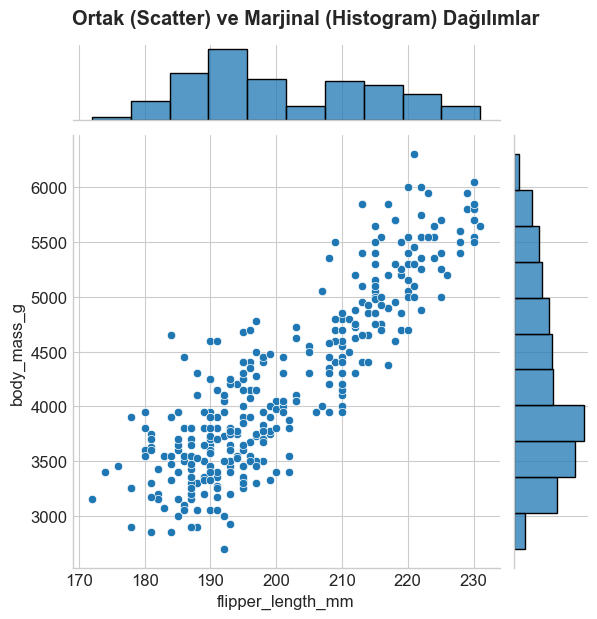

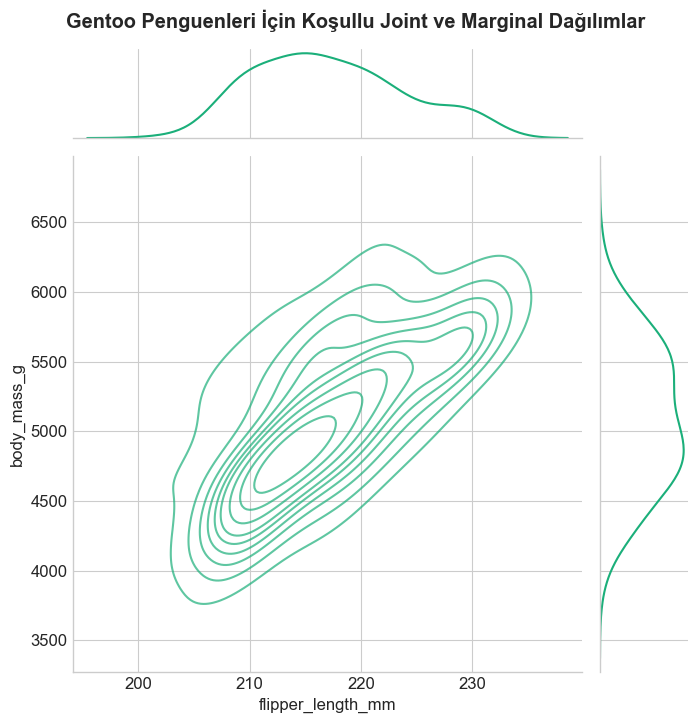

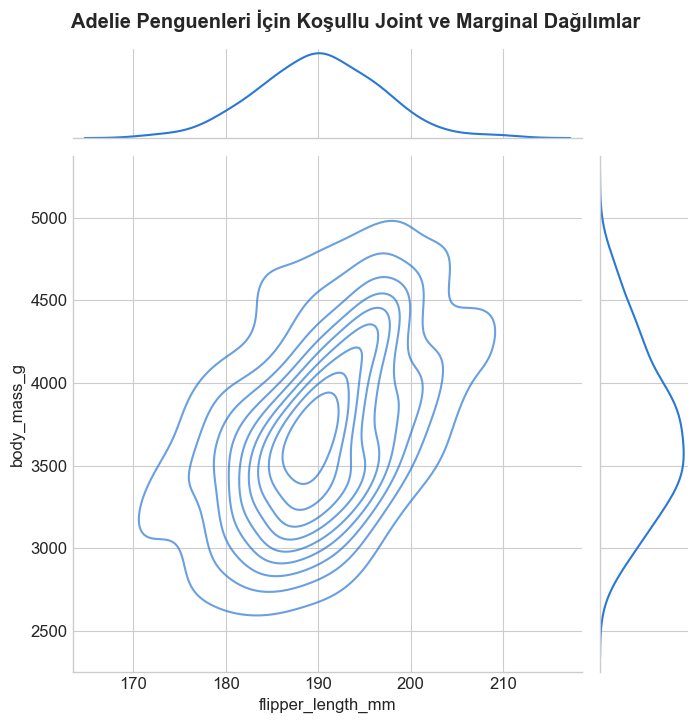

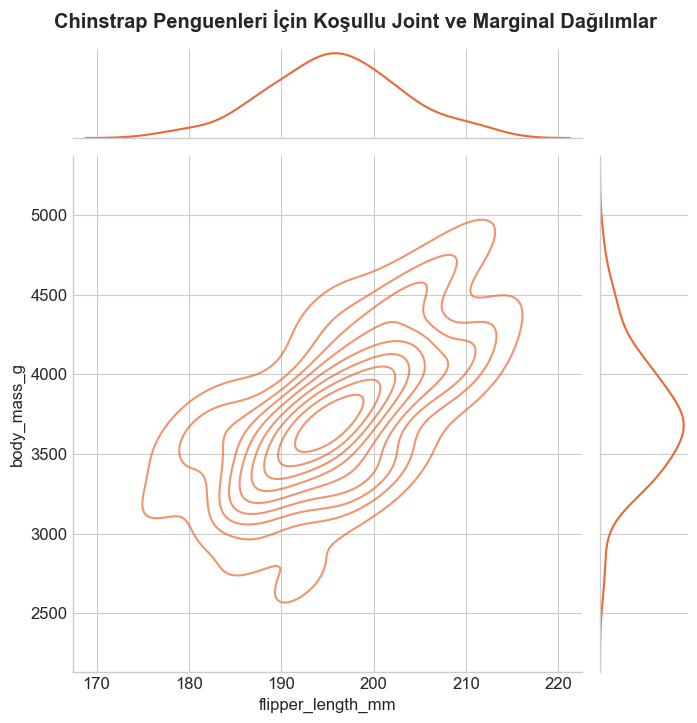

In [14]:
print("\n ==== Egzersiz 1: Marjinal ve Koşullu Dağılımları Görselleştir ===")

g = sns.jointplot(
    data=penguins,
    x="flipper_length_mm",
    y="body_mass_g",
    kind="scatter"
)
g.fig.suptitle('Ortak (Scatter) ve Marjinal (Histogram) Dağılımlar', y=1.03, fontweight='bold')
plt.show()

gentoo_penguins = penguins[penguins['species'] == 'Gentoo']
adelie_penguins = penguins[penguins['species'] == 'Adelie']
chinstrap_penguins = penguins[penguins['species'] == 'Chinstrap']


species_colors = {'Gentoo': '#1baf7a', 'Adelie': '#2a78d6', 'Chinstrap': '#eb6834'}
for name, subset in [('Gentoo', gentoo_penguins), ('Adelie', adelie_penguins), ('Chinstrap', chinstrap_penguins)]:
    g_species = sns.jointplot(
        data=subset,
        x="flipper_length_mm",
        y="body_mass_g",
        kind="kde",
        height=7,
        alpha=0.7,
        color=species_colors[name]
    )
    g_species.fig.suptitle(f'{name} Penguenleri İçin Koşullu Joint ve Marginal Dağılımlar', y=1.03, fontweight='bold')
    plt.show()


---
### E2 — Diamonds: Koşullu Olasılık ve Beklenti
a) `diamonds` veri setinde `carat` (Karat) büyüklüğünü üç gruba ayır (Örn: < 1.0 Düşük, 1.0 - 2.0 Orta, > 2.0 Yüksek). Python'da her grup için `price` (fiyat) dağılımını `sns.kdeplot(hue=grup_kolonu)` ile aynı grafik üzerinde çiz.

b) SQL (DuckDB) kullanarak, her bir `color` (renk) kalitesi için ortalama fiyatı (Yani $E[\text{Price} \mid \text{Color}]$) hesapla. Rengi en kötü olan (J) elmasların ortalama fiyatının, rengi en iyi olanlardan (D, E) yüksek çıkma sebebi sence ne olabilir? (İpucu: Marjinal ortalamalar her zaman tüm gerçeği yansıtmaz, ortak dağılımdaki diğer etkenler, örn: Karat, durumu bozabilir).

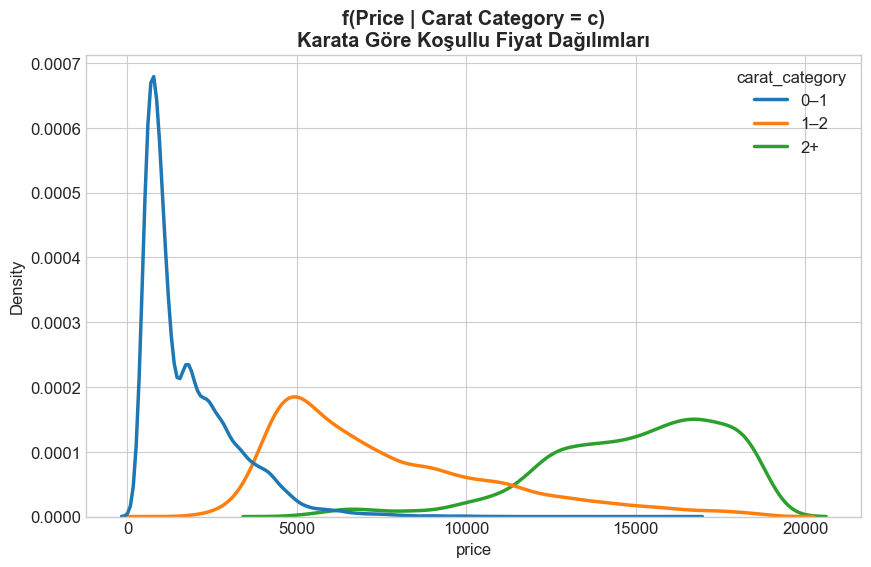

               renk  gozlem_sayisi  beklenen_fiyat
                  J           2808         5323.82
                  I           5422         5091.87
                  H           8304         4486.67
                  G          11292         3999.14
TÜM VERİ (Marjinal)          53940         3932.80
                  F           9542         3724.89
                  D           6775         3169.95
                  E           9797         3076.75


In [10]:
diamonds['carat_category'] = pd.cut(
    diamonds['carat'],
    bins=[0, 1, 2, np.inf],
    labels=['0–1', '1–2', '2+'],
    include_lowest=True
)
sns.kdeplot(data=diamonds, x='price', hue='carat_category', common_norm=False, linewidth=2.5)
plt.title('f(Price | Carat Category = c)\nKarata Göre Koşullu Fiyat Dağılımları', fontweight='bold')
plt.show()

color_sql = con.execute("""
WITH marginal AS (
    SELECT 
        'TÜM VERİ (Marjinal)' AS renk,
        COUNT(*) AS gozlem_sayisi,
        ROUND(AVG(price), 2) AS beklenen_fiyat
    FROM diamonds_tbl
),
-- 2. Koşullu Beklenti E[Price | Color=c]
conditional AS (
    SELECT 
        color AS renk,
        COUNT(*) AS gozlem_sayisi,
        ROUND(AVG(price), 2) AS beklenen_fiyat
    FROM diamonds_tbl
    GROUP BY color
)
-- Birlestirelim
SELECT * FROM marginal
UNION ALL
SELECT * FROM conditional
ORDER BY beklenen_fiyat DESC;
""").df()

print(color_sql.to_string(index=False))

---
### E3 — California Housing: Çok Değişkenli Koşullu (Sklearn)
a) `sklearn.datasets.fetch_california_housing` kullanarak veriyi DataFrame'e çevir. `MedInc` (Medyan Gelir) ekseni X, `MedHouseVal` (Ev Fiyatı) ekseni Y olacak şekilde bir `sns.jointplot(kind='hex')` çiz. İki değişken arasındaki ortak dağılım eğilimi (korelasyon sinyali) nasıl gözüküyor?

b) `HouseAge` (Ev Yaşı) değişkenini kullanarak veriyi koşulla: 
- Genç Evler (`HouseAge <= 20`)
- Eski Evler (`HouseAge > 20`)
Python'da bu iki koşul için `MedHouseVal`'in (fiyatın) marjinal yoğunluklarını (KDE) aynı grafikte karşılaştır. Geçmiş konuları (Log-Normal/Gamma) düşünerek: Fiyatların dağılımı sağa çarpık mı? Hangi grubun (Genç vs Eski) sağ kuyruğu (çok pahalı evler) daha kalındır?


California Housing Yuklendi: 20640 satir, 8 ozellik


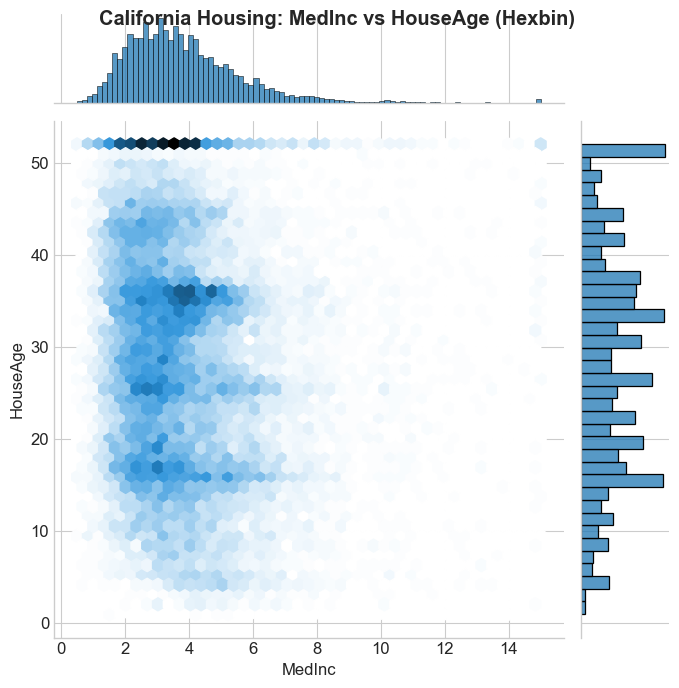

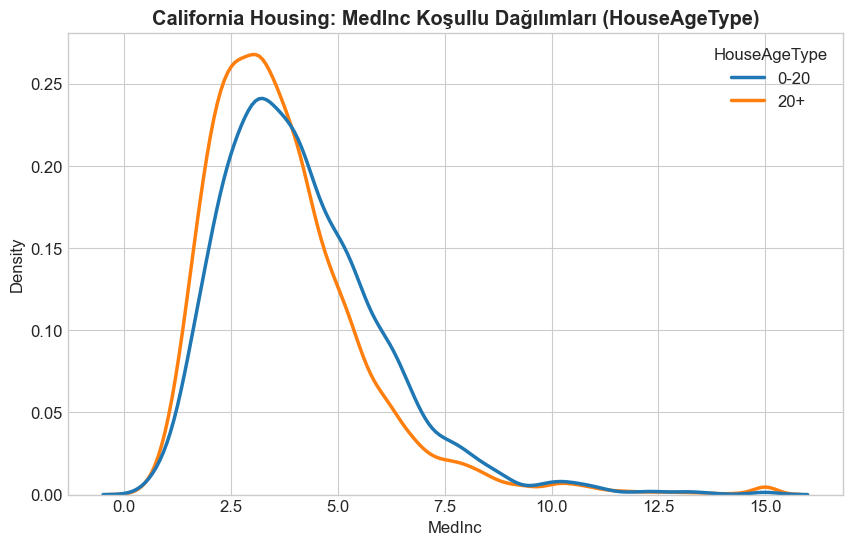

In [11]:
import sklearn.datasets
california_housing = sklearn.datasets.fetch_california_housing()
print(f'California Housing Yuklendi: {len(california_housing.data)} satir, {len(california_housing.feature_names)} ozellik')

sns.jointplot(
    data = pd.DataFrame(california_housing.data, columns=california_housing.feature_names),
    x = "MedInc",
    y = "HouseAge",
    kind = "hex",
    height = 7,
)
plt.suptitle('California Housing: MedInc vs HouseAge (Hexbin)', fontweight='bold')
plt.show()

california_df = pd.DataFrame(california_housing.data, columns=california_housing.feature_names)
california_df["HouseAgeType"] =pd.cut(
    california_df["HouseAge"],
    bins =[0,20,np.inf],
    labels = ["0-20","20+"],
    include_lowest = True
)

sns.kdeplot(
    data = california_df,
    x = "MedInc",
    hue = "HouseAgeType",
    common_norm = False,
    linewidth = 2.5
)
plt.title('California Housing: MedInc Koşullu Dağılımları (HouseAgeType)', fontweight='bold')
plt.show()

### E5 (SQL) — Penguins: Marjinal vs Koşullu Beklenti (DuckDB)
`penguins_tbl` üzerinde SQL ile $E[\text{body\_mass\_g}]$ marjinalini VE her `island` için koşullu $E[\text{body\_mass\_g} \mid \text{island}]$'ı tek bir sorguda (yukarıdaki elmas örneğindeki UNION ALL kalıbıyla) hesapla.

In [12]:
sql_ex5 = con.execute("""
WITH marginal AS (
    SELECT 'TÜM VERİ (Marjinal)' AS ada, COUNT(*) AS n, ROUND(AVG(body_mass_g), 1) AS ortalama_kutle
    FROM penguins_tbl
),
conditional AS (
    SELECT island AS ada, COUNT(*) AS n, ROUND(AVG(body_mass_g), 1) AS ortalama_kutle
    FROM penguins_tbl
    GROUP BY island
)
SELECT * FROM marginal
UNION ALL
SELECT * FROM conditional
ORDER BY ortalama_kutle DESC;
""").df()
print("=== E[body_mass_g]: Marjinal vs Adaya Göre Koşullu ===")
print(sql_ex5.to_string(index=False))


=== E[body_mass_g]: Marjinal vs Adaya Göre Koşullu ===
                ada   n  ortalama_kutle
             Biscoe 163          4719.2
TÜM VERİ (Marjinal) 333          4207.1
              Dream 123          3718.9
          Torgersen  47          3708.5


---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [Prob4DS — Stanley Chan](https://probability4datascience.com) | Ch. 5 | Joint/Marginal/Conditional dağılımlar |
| [Harvard STAT 110](https://youtube.com/playlist?list=PL2SOU6wwxB0uwwH80KTQ6ht66KWxbzTIo) | Ders 15–17 | Joint distributions, conditioning |
| [Seeing Theory](https://seeing-theory.brown.edu/joint-distributions) | Joint Distributions | İnteraktif görselleştirme |
| [Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/) | Veri | Veri seti dokümantasyonu |